In [35]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load the topological data
topology_df = pd.read_csv('topology_data_logical.csv')

# Clean the data (remove duplicates, handle missing values, etc.)
topology_df = topology_df.drop_duplicates()
topology_df = topology_df.dropna(subset=['aendname', 'bendname'])
topology_df = topology_df[topology_df['distance']!=0]



In [36]:
alarm_df = pd.read_csv('berla_alarms.csv')




In [37]:
# Create a graph
G = nx.Graph()

# Add edges to the graph
for _, row in topology_df.iterrows():
    G.add_edge(row['aendname'], row['bendname'], weight=row['distance'])

# Add node attributes
for _, row in topology_df.iterrows():
    G.nodes[row['aendname']]['ip'] = row['aendip']
    G.nodes[row['bendname']]['ip'] = row['bendip']


C:\Users\user\AppData\Local\Temp\ipykernel_26348\2908510267.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


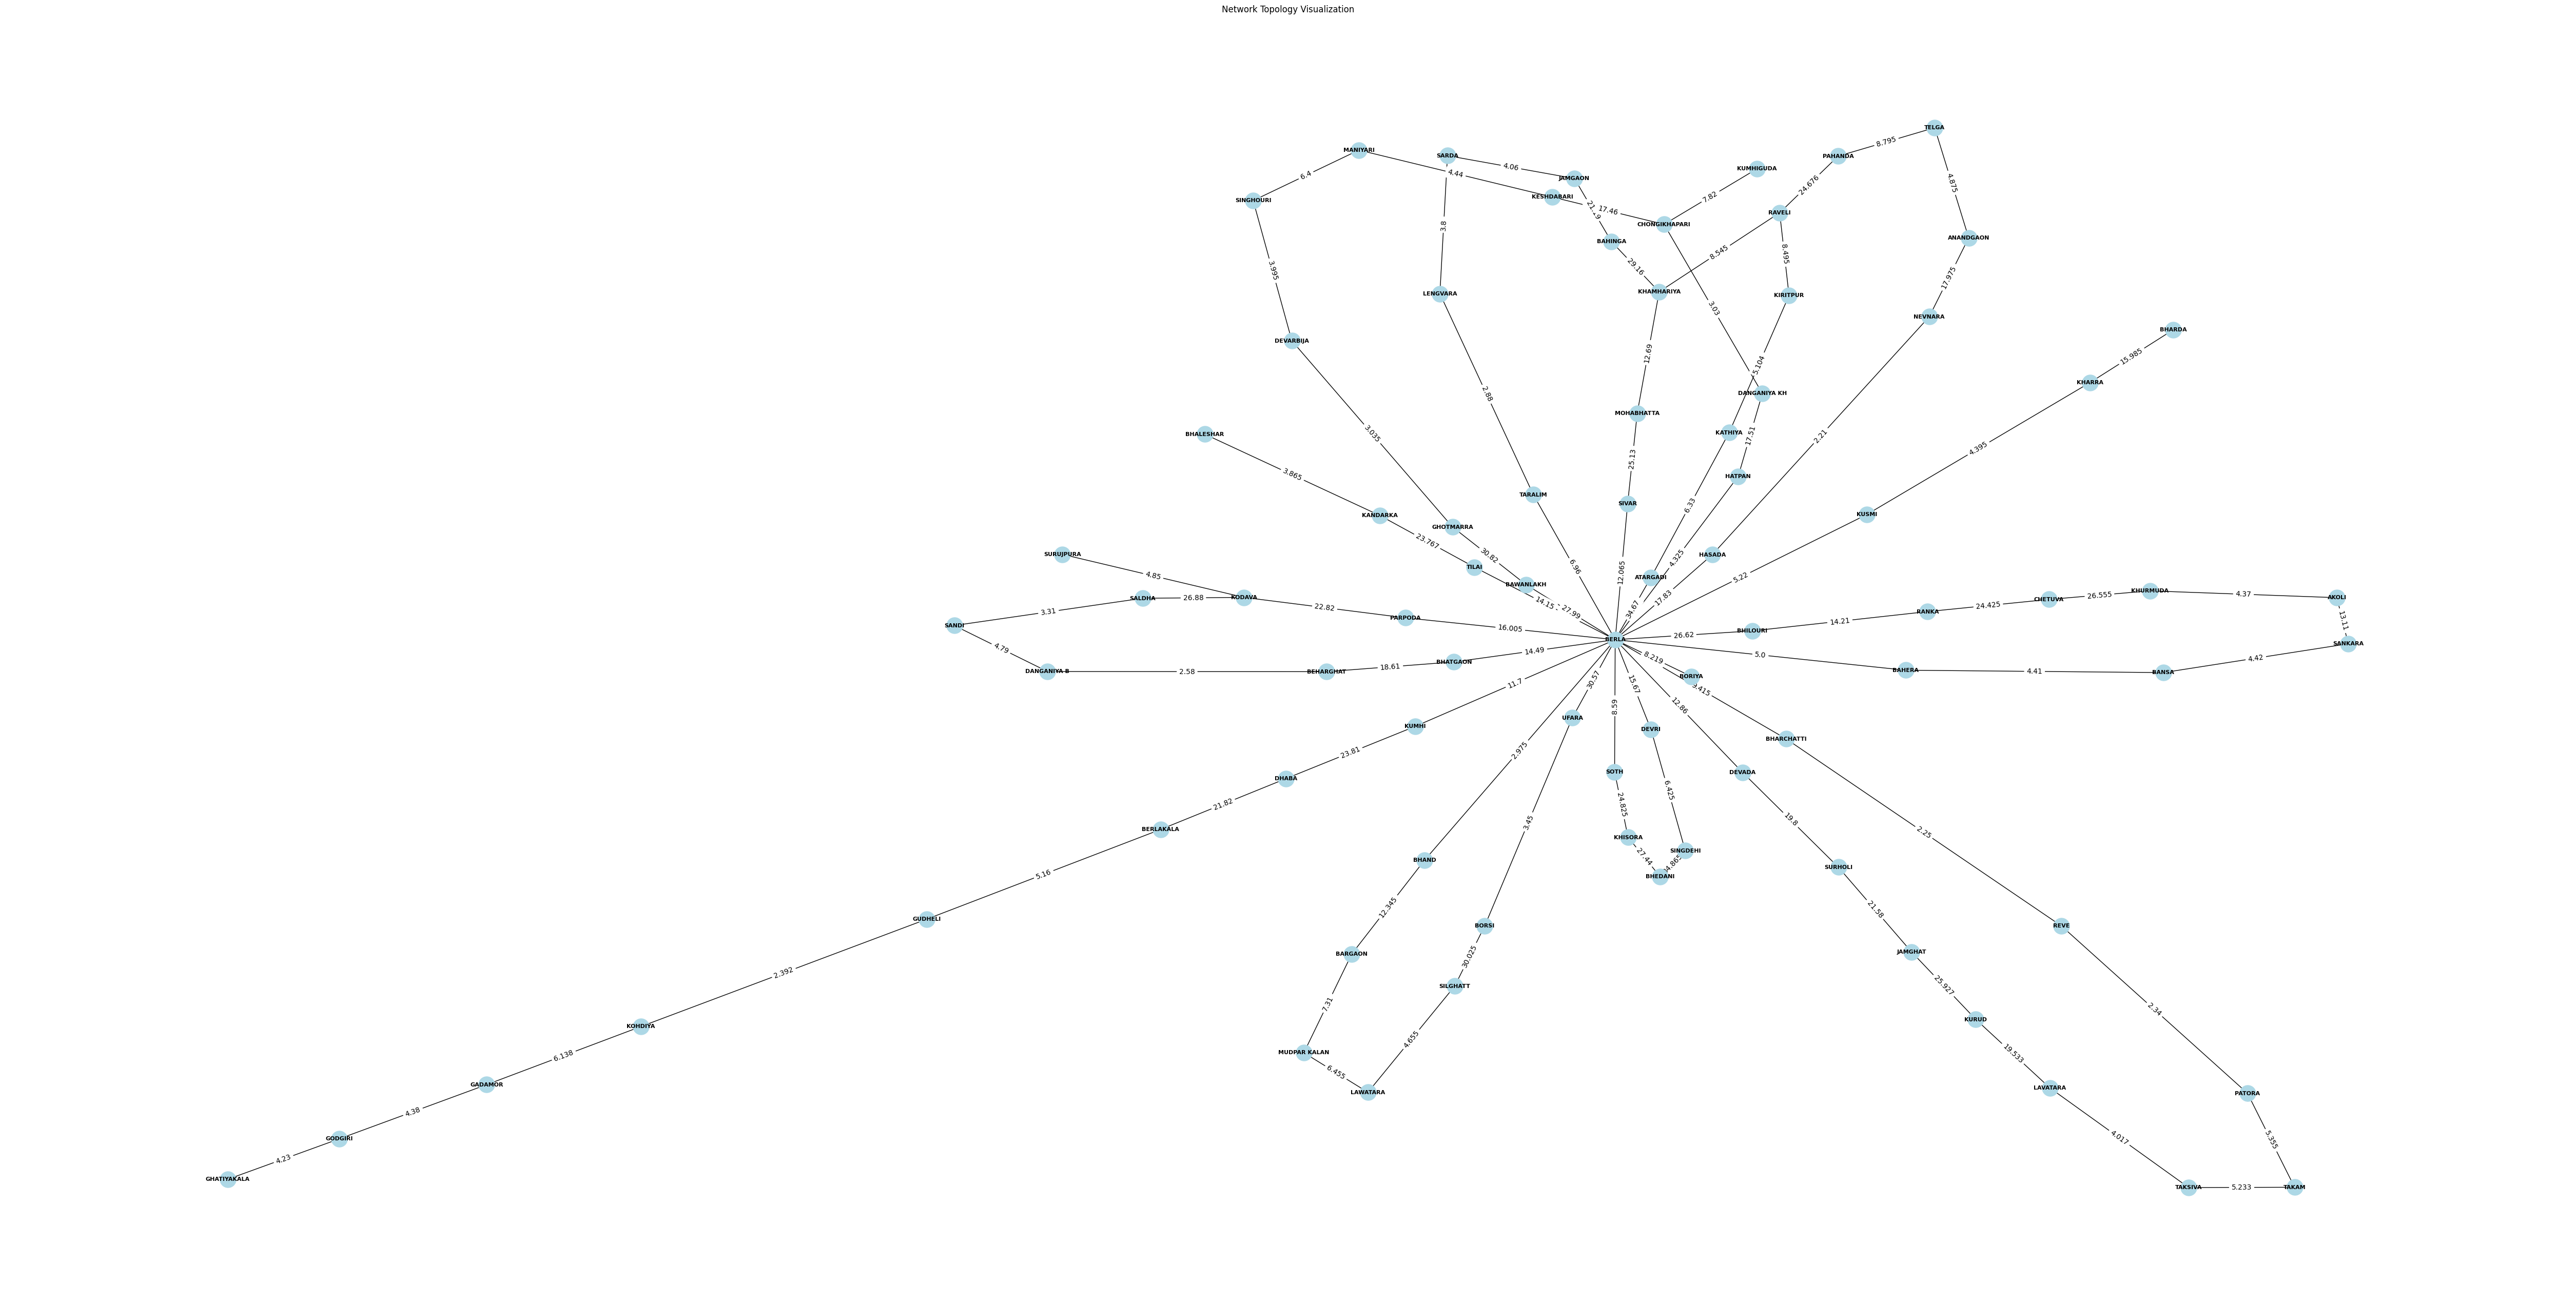

In [38]:
# Set up the plot
plt.figure(figsize=(50, 25))

# Draw the network
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', 
        node_size=500, font_size=8, font_weight='bold')

# Add edge labels (distances)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Network Topology Visualization")
plt.axis('off')
plt.tight_layout()
plt.show()


In [55]:
if_descriptions = {}

if_descriptions['10.128.0.16-10.128.17.86'] = 'GigabitEthernet0/1/0/9'
if_descriptions['10.128.17.86-10.128.0.16'] = 'TenGigabitEthernet0/0/12'
print(if_descriptions)

{'10.128.0.16-10.128.17.86': 'GigabitEthernet0/1/0/9', '10.128.17.86-10.128.0.16': 'TenGigabitEthernet0/0/12'}


In [90]:
import mysql.connector

mydb = mysql.connector.connect(
      host="192.168.30.15",
      user="nms",
      password="Nms@1234",
      database="cnmsip"
    )
cursor = mydb.cursor(buffered=True,dictionary=True)

In [83]:
import uuid
from datetime import datetime

def insert_link_down_alarms(connection_str cursor=cursor):
    """
    Inserts two alarm rows into the alarm table for a given connection string.
    Each alarm uses the interface description where the respective IP is the left-hand side in the dictionary key.
    
    :param connection_str: A string in the format 'ip1-ip2' indicating the connection that went down.
    :param if_descriptions: A dictionary with keys in 'ip1-ip2' format mapping to interface descriptions (left-hand side IP's interface).
    :param cursor: MySQL database cursor to execute the insert statements.
    """
    connection_str = connection_str.lower()
    input_ips = connection_str.split('-')
    if len(input_ips) != 2:
        raise ValueError("Connection string must be in the format 'ip1-ip2'.")
    
    # Validate both possible keys exist in the dictionary


    
    # Generate alarms for each IP with their respective interface descriptions
    for index,ip in enumerate(input_ips): 
        obj_type = "BLOCK_ROUTER" if ip == "10.128.0.16" else "GP_ROUTER"
        current_time = datetime.now()
        alarm_id = f"LIN_{current_time.strftime('%Y%m%d%H%M%S')}_{uuid.uuid4().hex[:12]}"
        notif_id = f"RAI_{alarm_id}"
        ifIndex = 13+index
        # Construct additional info with interface description from the dictionary
        addi_info = f"IF_DESCR=GigabitEthernet0/0/{ifIndex};IF_TYPE=6;REASON=administratively down;ENGINE_ID=80:00:00:09:03:00:f8:0f:6f:05:91:80;SYS_TIME=8000"
        
        # Determine interface number based on order in the input connection string (1-based)
        interface_number = str(input_ips.index(ip) + 1)
        
        # Prepare data for insertion
        alarm_data = (
            alarm_id,
            notif_id,
            current_time,  # NE_TIME
            ip,            # OBJ_NAME
            obj_type,   # OBJ_TYPE
            ip,            # RES_NAME
            current_time,  # EMS_TIME
            "link_down",   # PROB_CAUSE
            1,             # PERC_SEVERITY
            1,             # NMS_SEVERITY
            addi_info,     # ADDI_INFO
            1,             # RCA_INDICATOR
            None,          # RCA_ID
            0,             # VISIBLE
            None,          # TT_ID
            current_time,  # LOG_TIME
            1195,          # LOCATION_ID (from sample data)
            2,             # PROCESS_FLAG (from sample data)
            "Interface Admin Status is DOWN",  # REMARKS
            "LINK ALARMS", # CATEGORY
            interface_number,  # interface
            None,          # RFO
            None,          # FIBER_DETAILS
            None,          # LATEST_RFO
            None,          # PREVIOUS_TT_ID
            None,          # PREVIOUS_RCA_ID
            None           # UPS_BATTERY_PERCENT
        )
        
        # SQL insert statement
        insert_query = """
            INSERT INTO alarm (
                ID, NOTIF_ID, NE_TIME, OBJ_NAME, OBJ_TYPE, RES_NAME, EMS_TIME,
                PROB_CAUSE, PERC_SEVERITY, NMS_SEVERITY, ADDI_INFO, RCA_INDICATOR,
                RCA_ID, VISIBLE, TT_ID, LOG_TIME, LOCATION_ID, PROCESS_FLAG, REMARKS,
                CATEGORY, interface, RFO, FIBER_DETAILS, LATEST_RFO, PREVIOUS_TT_ID,
                PREVIOUS_RCA_ID, UPS_BATTERY_PERCENT
            ) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
        """
        
        cursor.execute(insert_query, alarm_data)
        cursor.fetchall()
    
    mydb.commit()

In [63]:
print(datetime.now())

2025-01-27 14:56:46.602552


InterfaceError: No result set to fetch from

In [84]:
connection_str = '10.128.0.16-10.128.17.86'
insert_link_down_alarms(connection_str,if_descriptions)

In [105]:

import time
from mysql.connector import Error
from itertools import combinations

def parse_addi_info(addi_info):
    """Parse ADDI_INFO field into a dictionary of key-value pairs."""
    return {k: v for k, v in (item.split('=', 1) for item in addi_info.split(';'))} if addi_info else {}

def get_if_index(cursor, ip, if_descr):
    """Retrieve ifIndex from nw_interface_detail for given IP and interface description."""
    cursor.execute("""
        SELECT ifIndex 
        FROM nw_interface_detail 
        WHERE ip = %s AND ifDescription = \"%s\"
    """, (ip, if_descr))
    result = cursor.fetchone()
    return result['ifIndex'] if result else None

def check_topology_link(cursor, ip1, ifindex1, ip2, ifindex2):
    """Check if the IP/interface pair exists in topology_data_logical."""
    cursor.execute("""
        SELECT id 
        FROM topology_data_logical 
        WHERE (
            (aendip = %s AND bendip = %s AND aendifIndex = %s AND bendifIndex = %s) 
            OR 
            (aendip = %s AND bendip = %s AND aendifIndex = %s AND bendifIndex = %s)
        )
    """, (ip1, ip2, ifindex1, ifindex2, ip2, ip1, ifindex2, ifindex1))
    return cursor.fetchone() is not None

def process_alarm_group(cursor, group):
    """Process a group of alarms and print fiber cut notifications"""
    interface_pairs = []
    
    # Collect interface information
    for alarm in group:
        ip = alarm['OBJ_NAME']
        addi_info = alarm['ADDI_INFO']
        parsed_info = parse_addi_info(addi_info)
        print(ip)
        print(addi_info)
        print(parsed_info)
        if_descr = parsed_info.get('IF_DESCR')
        if not if_descr:
            print('')
            continue
        print(if_descr)
        ifindex = get_if_index(cursor, ip, if_descr)
        print(ifindex)
        if ifindex:
            interface_pairs.append((ip, ifindex))
    
    # Check all possible pairs
    fiber_cuts = set()
    for (ip1, ifindex1), (ip2, ifindex2) in combinations(interface_pairs, 2):
        if check_topology_link(cursor, ip1, ifindex1, ip2, ifindex2):
            # Sort IPs to avoid duplicate reporting
            sorted_ips = tuple(sorted([ip1, ip2]))
            fiber_cuts.add(sorted_ips)
    
    # Print results
    for ip_pair in fiber_cuts:
        print(f"Fiber cut detected between {ip_pair[0]} and {ip_pair[1]}")
        print(f"Affected interfaces:")
        print(f"- {ip_pair[0]} (ifIndex: {next(x[1] for x in interface_pairs if x[0] == ip_pair[0])})")
        print(f"- {ip_pair[1]} (ifIndex: {next(x[1] for x in interface_pairs if x[0] == ip_pair[1])})")
        print(f"Timestamp: {group[0]['NE_TIME']}\n")
    

In [106]:


try:
    # Database configuration



    # Initialize last processed time
    cursor.execute("SELECT MAX(NE_TIME) AS last_time FROM alarm")
    # last_processed = cursor.fetchone()['last_time'] or '1970-01-01'
    last_processed = '2025-01-27 16:30:00'

    # Continuous monitoring loop
    
        # Fetch new link_down alarms
    cursor.execute("""
        SELECT * FROM alarm 
        WHERE PROB_CAUSE = 'link_down' 
            AND NE_TIME > %s
        ORDER BY NE_TIME
    """, (last_processed,))
    new_alarms = cursor.fetchall()

    if new_alarms:
        # Group alarms by NE_TIME
        groups = {}
        for alarm in new_alarms:
            groups.setdefault(alarm['NE_TIME'], []).append(alarm)
        
        # Process each time-synchronized group
        for ne_time, group in groups.items():
            process_alarm_group(cursor, group)
            mydb.commit()
        
        # Update last processed timestamp
        # last_processed = max(a['NE_TIME'] for a in new_alarms)
    else:
        print("No new alarms")
        # Check every 5 seconds

except Error as e:
    print(f"Database Error: {e}")




10.128.17.86
IF_DESCR=TenGigabitEthernet0/0/12;IF_TYPE=6;REASON=administratively down;ENGINE_ID=80:00:00:09:03:00:f8:0f:6f:05:91:80;SYS_TIME=8000
{'IF_DESCR': 'TenGigabitEthernet0/0/12', 'IF_TYPE': '6', 'REASON': 'administratively down', 'ENGINE_ID': '80:00:00:09:03:00:f8:0f:6f:05:91:80', 'SYS_TIME': '8000'}
TenGigabitEthernet0/0/12
None
10.128.0.16
IF_DESCR=GigabitEthernet0/1/0/9;IF_TYPE=6;REASON=administratively down;ENGINE_ID=80:00:00:09:03:00:f8:0f:6f:05:91:80;SYS_TIME=8000
{'IF_DESCR': 'GigabitEthernet0/1/0/9', 'IF_TYPE': '6', 'REASON': 'administratively down', 'ENGINE_ID': '80:00:00:09:03:00:f8:0f:6f:05:91:80', 'SYS_TIME': '8000'}
GigabitEthernet0/1/0/9
None


In [ ]:

    if new_alarms:
        # Group alarms by NE_TIME
        groups = {}
        for alarm in new_alarms:
            groups.setdefault(alarm['NE_TIME'], []).append(alarm)
        
        # Process each time-synchronized group
        for ne_time, group in groups.items():
            process_alarm_group(cursor, group)
            mydb.commit()
        
        # Update last processed timestamp
        last_processed = max(a['NE_TIME'] for a in new_alarms)
    else:
        print("No new alarms")
        # Check every 5 seconds

except Error as e:
    print(f"Database Error: {e}")




In [28]:
G = nx.Graph()

# Add edges to the graph
for _, row in topology_df.iterrows():
    G.add_edge(row['aendname'], row['bendname'], weight=row['distance'])

# Add node attributes
for _, row in topology_df.iterrows():
    G.nodes[row['aendname']]['ip'] = row['aendip']
    G.nodes[row['bendname']]['ip'] = row['bendip']

# Map alarms to nodes
for _, alarm in alarm_df.iterrows():
    for node, data in G.nodes(data=True):
        if data.get('ip') == alarm['OBJ_NAME']:
            G.nodes[node]['alarm'] = alarm['PROB_CAUSE']
            G.nodes[node]['rca'] = alarm['RCA_INDICATOR']


C:\Users\user\AppData\Local\Temp\ipykernel_26348\3669723830.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


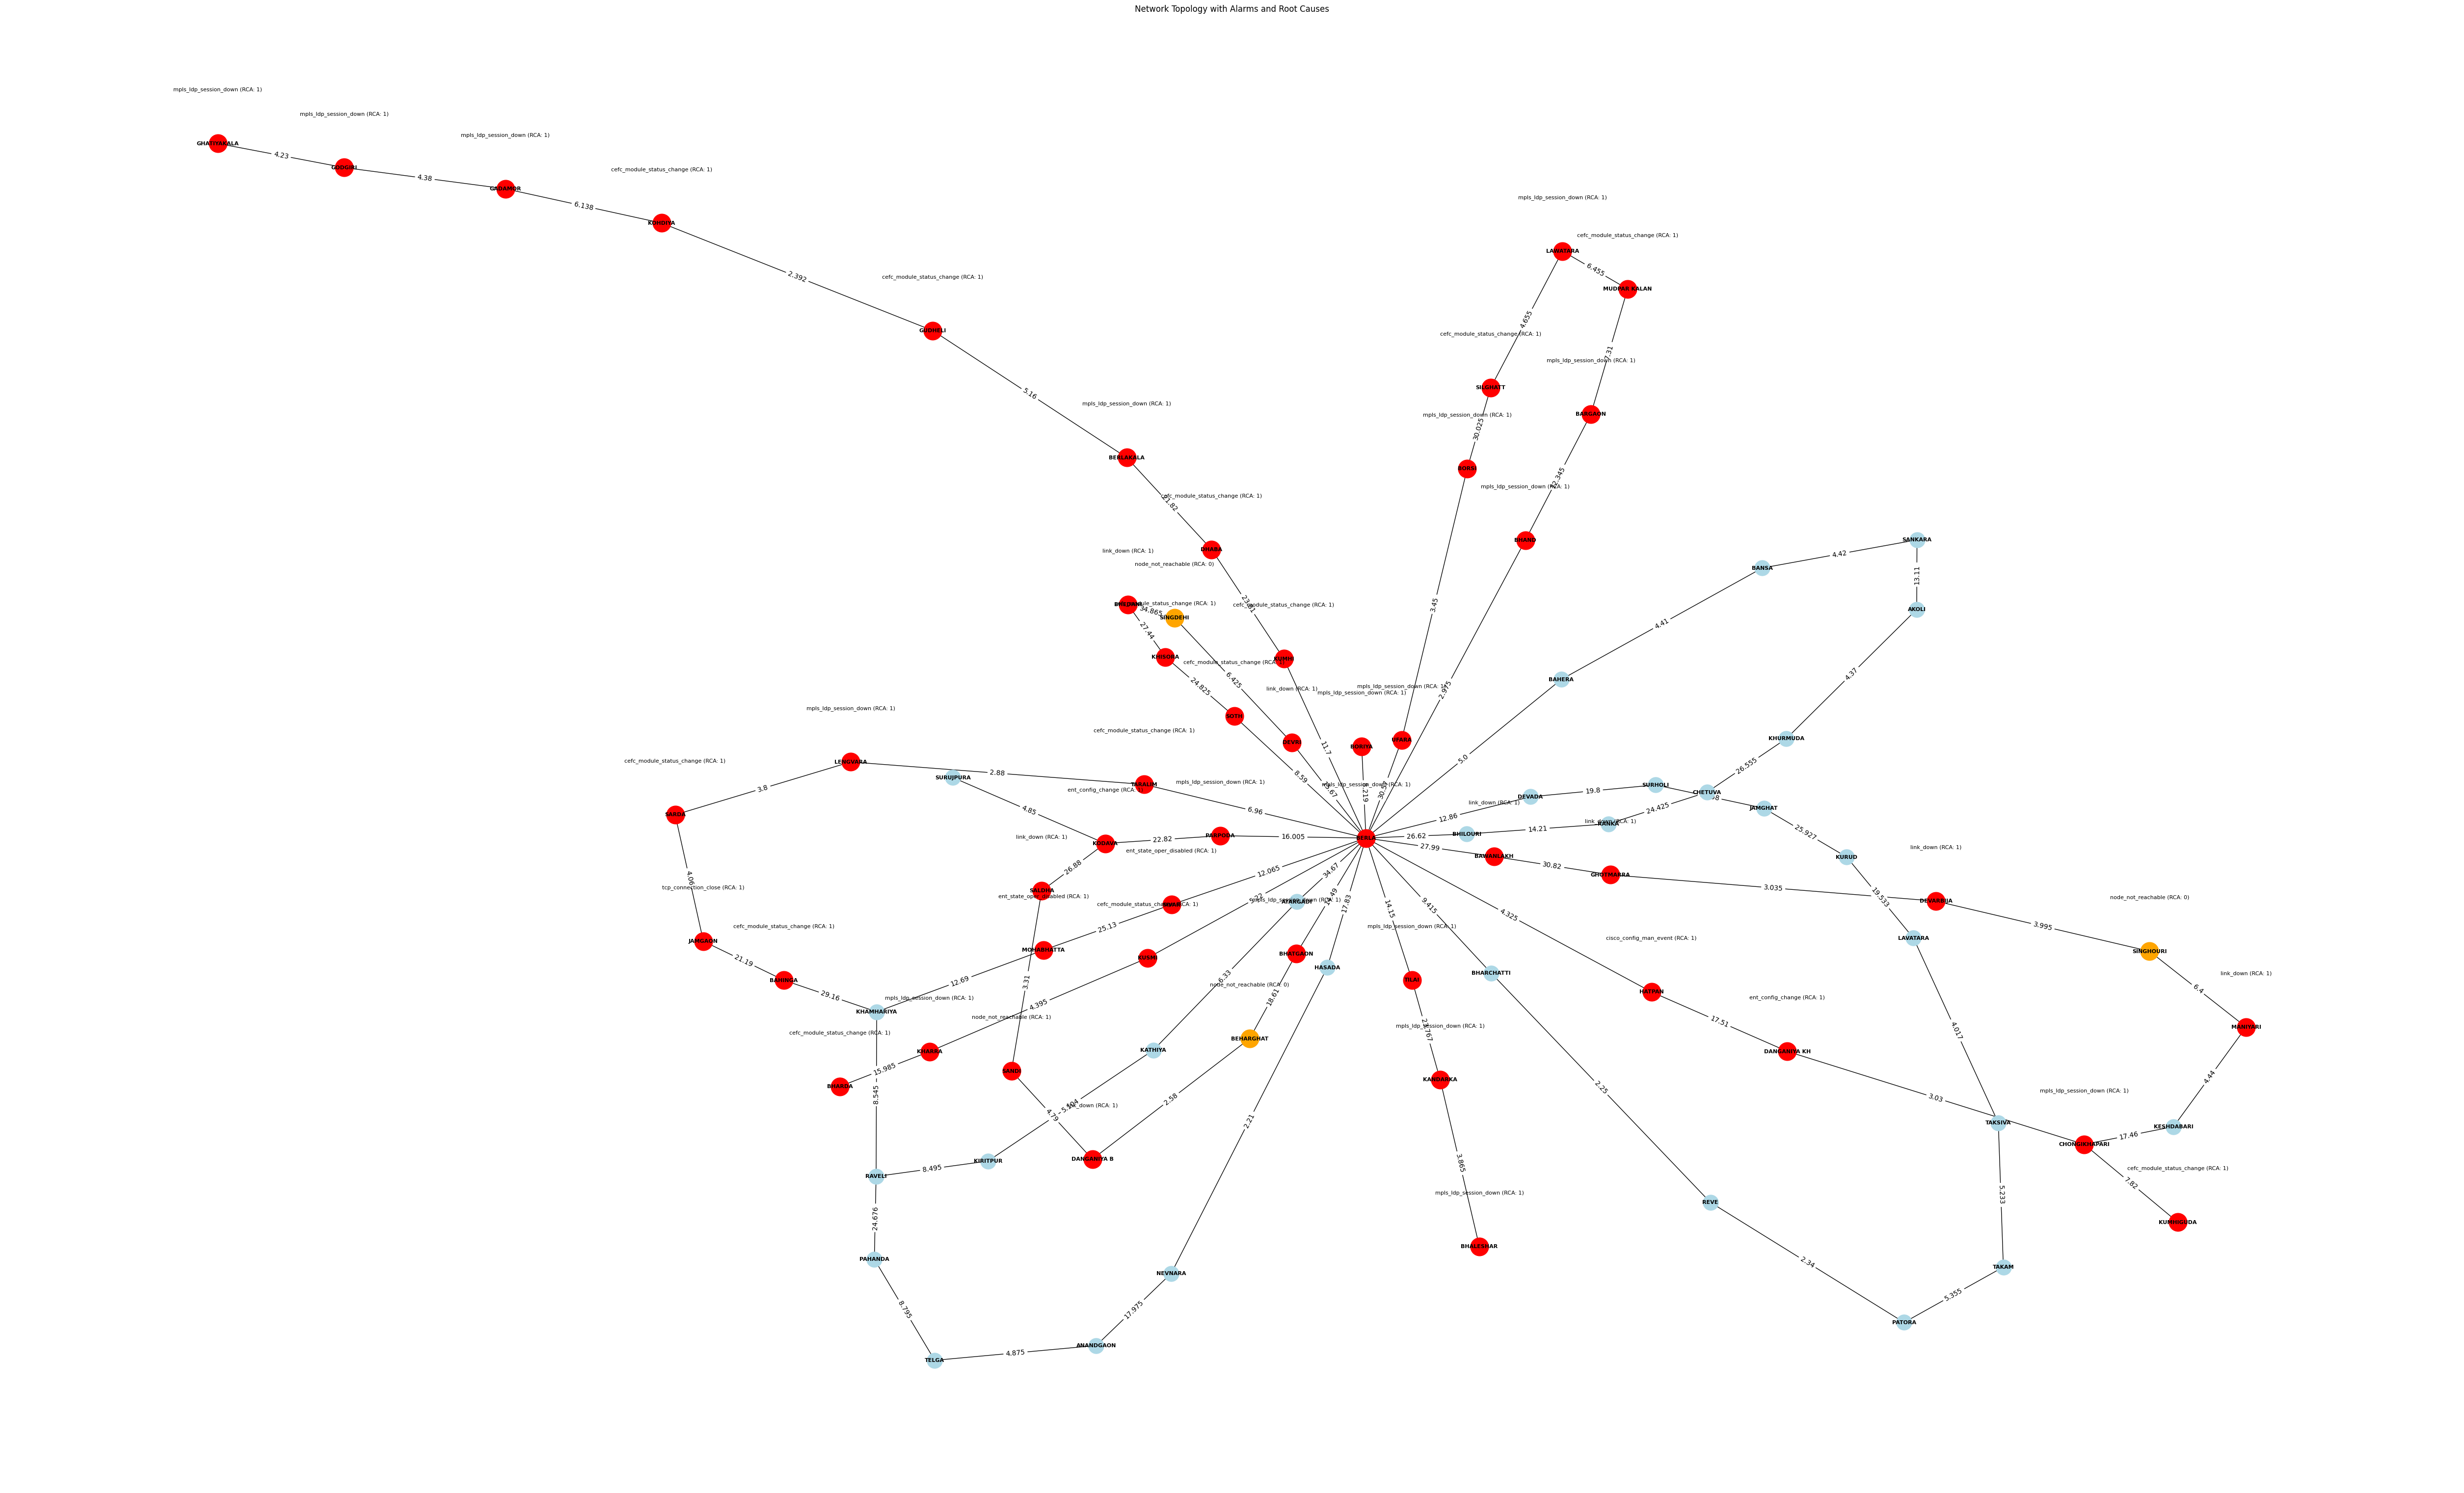

In [33]:

# Visualize the graph
plt.figure(figsize=(50, 30))
pos = nx.spring_layout(G)

# Draw the network
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500, font_size=8, font_weight='bold')

# Highlight nodes with alarms
for node, data in G.nodes(data=True):
    if 'alarm' in data:
        color = 'red' if data['rca'] == 1 else 'orange'
        nx.draw_networkx_nodes(G, pos, nodelist=[node], node_color=color, node_size=700)

y_values = [pos[node][1] for node in G.nodes]
y_range = max(y_values) - min(y_values)
offset = y_range * 0.05

for node, data in G.nodes(data=True):
    if 'alarm' in data:
        label = f"{data['alarm']} (RCA: {data.get('rca')})"
        plt.text(pos[node][0], pos[node][1] + 0.05, label, fontsize=8, ha='center')

# Add edge labels (distances)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Network Topology with Alarms and Root Causes")
plt.axis('off')
plt.tight_layout()
plt.show()

In [24]:
root_cause_ips = alarm_df[alarm_df['RCA_INDICATOR'] == 1]['OBJ_NAME']
topology_ips = set(topology_df['aendip']).union(set(topology_df['bendip']))
root_cause_in_topology = root_cause_ips.isin(topology_ips).sum()
non_root_cause_ips = alarm_df[alarm_df['RCA_INDICATOR'] == 0]['OBJ_NAME']
non_root_cause_in_topology = non_root_cause_ips.isin(topology_ips).sum()


In [27]:
print(non_root_cause_in_topology)

50


In [18]:
print(root_cause_in_topology)

0
